#### Tech Challenge - Fase 1 - Data Analysis and Exploration

**Contexto**

Atuando como Expert em Data Analytics em uma empresa que exporta vinhos do Brasil para o mundo todo em uma área recém-criada dentro da empresa sendo responsável pelos relatórios iniciais a serem apresentados, explicando a quantidade de vinhos exportados e os fatores externos que podem vir a surgir e que interferem nas análises:

1. Dados climáticos
2. Dados demográficos
3. Dados econômicos
4. Dados de avaliações de vinhos

Sendo necessario a criação de uma tabela contendo as seguintes informações:

a. País de origem (Brasil)
b. País de destino
c. Quantidade em litros de vinho exportado (utilize: 1KG =1L)
d. Valor em US$

Com os dados fornecido de vinícola parceira e que podem ser encontrados aqui através do seguinte link:

 http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01

##### Importação de pacotes, bibliotecas e criação de funções (DEF)

In [156]:
# Importar biblioteca completa
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importar função especifica de um módulo
from datetime import datetime
from IPython.display import display

In [157]:
# Função para identificar sequências consecutivas
def encontrar_sequencias_consecutivas(anos, min_consecutivos):
    anos = sorted(anos)
    sequencia = []
    resultado = []
    
    for ano in anos:
        if not sequencia or ano == sequencia[-1] + 1:
            sequencia.append(ano)
        else:
            if len(sequencia) >= min_consecutivos:
                resultado.append(sequencia)
            sequencia = [ano]
    
    # Checar última sequência
    if len(sequencia) >= min_consecutivos:
        resultado.append(sequencia)
    
    return resultado

##### Tratar base de dados

In [158]:
# Como o delimitador do arquivo exportado é o espaço, foi necesasrio tratar o arquivo de uma maneira diferente para garantir a criação correta do Data Frma 

# Caminho onde esta o arquivo
caminho_arquivo = r"C:\Users\ricar\OneDrive\Cursos\Pós Graduação\Data Analytics - FIAP\02 - Fase 1 - Data Analysis and Exploration\05 - Atividade a ser entregue até 03_06 - Em grupo\Base\ExpVinho.csv"

# Lista vazia para armazenar os dados
dados = []

with open(caminho_arquivo, encoding='utf-8') as f:
    linhas = f.readlines()

# Separar o cabeçalho original
cabecalho_raw = linhas[0].strip().split()

# Definir colunas iniciais fixas
colunas = ['Id', 'País']

# Selecionar os anos
anos = cabecalho_raw[2:]

# Agrupar pares de colunas por ano como 'Ano_Quantidade' e 'Ano_Valor'
for i in range(0, len(anos), 2):
    ano = anos[i]
    colunas.append(f"{ano}_quantidade_kg")
    colunas.append(f"{ano}_valor_usd")

# Lê os dados
for linha in linhas[1:]:
    partes = linha.strip().split()
    id = partes[0]

    # Juntar os campos do país até encontrar o início dos valores (número)
    i = 1
    while not partes[i].isdigit():
        i += 1
    pais = ' '.join(partes[1:i])
    valores = partes[i:]
    dados.append([id, pais] + valores)

# Criar o DataFrame e ajustar o nome
df_vinhos = pd.DataFrame(dados, columns=colunas)
df_vinhos = df_vinhos.rename(columns={'País': 'pais','Id':'id'})
df_vinhos.head()

,id,pais,1970_quantidade_kg,1970_valor_usd,1971_quantidade_kg,1971_valor_usd,1972_quantidade_kg,1972_valor_usd,1973_quantidade_kg,1973_valor_usd,...,2020_quantidade_kg,2020_valor_usd,2021_quantidade_kg,2021_valor_usd,2022_quantidade_kg,2022_valor_usd,2023_quantidade_kg,2023_valor_usd,2024_quantidade_kg,2024_valor_usd
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [159]:
# Despitovar e Pivotar a tabela, saindo de um modelo largo para um modelo longo

# Selecionar o nome das colunas
anos = df_vinhos.columns[2:]
anos

# Fazer um copia do data frame
df_vinhos_tratado = df_vinhos.copy() # Utilizando o .copy para copiar os dados do Data Frame e dessa forma, não precisar executar toda vez o notebook inteiro 

# Despivotar o data frame
df_vinhos_tratado = df_vinhos.melt(id_vars=['id','pais'],value_vars=anos, var_name='ano_tipo', value_name='valor') 

# Criar duas novas coluna com o ano e o tipo
df_vinhos_tratado['tipo'] = df_vinhos_tratado['ano_tipo'].str.split('_', n=1).str[1]
df_vinhos_tratado['ano'] = df_vinhos_tratado['ano_tipo'].str.split('_', n=1).str[0]

# Remover coluna não necessaria
df_vinhos_tratado = df_vinhos_tratado.drop(columns=['ano_tipo'])

# Pivotar a coluna tipo com o valor 
df_vinhos_tratado = df_vinhos_tratado.pivot(index=['id', 'pais', 'ano'],columns='tipo',values='valor')
df_vinhos_tratado = df_vinhos_tratado.reset_index()

# Converter colunas para o formato númerico
colunas_altercao = ['quantidade_kg','valor_usd','ano']
df_vinhos_tratado[colunas_altercao] = df_vinhos_tratado[colunas_altercao].apply(pd.to_numeric, errors='coerce')

# Filtrar ultimos dados e filtrar o primeiro pais - Validar com a base original (site)
df_vinhos_tratado.query('pais == "África do Sul"').tail()

tipo,id,pais,ano,quantidade_kg,valor_usd
2965,2,África do Sul,2020,4,21
2966,2,África do Sul,2021,0,0
2967,2,África do Sul,2022,0,0
2968,2,África do Sul,2023,117,698
2969,2,África do Sul,2024,103,1783


##### Analise do preço médio

Qual a elasticidade do preço por kg com relação à quantidade exportada?  
→ Análise econômica para entender se preço sobe ou cai com maior volume

In [160]:
# Limitar os ultimos anos qtd maior que zero
delta_anos = 15
ano_atual = datetime.now().year
limite = ano_atual-delta_anos

df_vinhos_ultimo = df_vinhos_tratado.copy()
df_vinhos_ultimo = df_vinhos_ultimo[(df_vinhos_ultimo['ano'] >=  limite) & (df_vinhos_ultimo['quantidade_kg'] > 0)].sort_values(by='ano')

df_vinhos_ultimo


tipo,id,pais,ano,quantidade_kg,valor_usd
2515,14,Bahamas,2010,3175,12759
4165,4,Angola,2010,33557,189891
5870,68,Haiti,2010,2700,3750
3120,22,Bolívia,2010,54,282
6695,81,Japão,2010,112178,74628
...,...,...,...,...,...
3739,32,China,2024,34231,182595
3629,30,"Cayman, Ilhas",2024,180,591
3464,28,Canadá,2024,4320,35179
5114,55,Filipinas,2024,11514,27378


In [161]:
# Verificar paises que existe uma recorrencia de compra 
paises_validos = []

for pais, grupo in df_vinhos_ultimo.groupby('pais'):
    sequencias = encontrar_sequencias_consecutivas(grupo['ano'].tolist(),15)
    if sequencias:
        paises_validos.append(pais)

# Filtrar DataFrame original com os países que têm sequência válida
df_vinhos_ultimo_filtro = df_vinhos_ultimo[df_vinhos_ultimo['pais'].isin(paises_validos)].copy()

In [162]:
# Agrupar os dados
df_vinhos_ultimo_rank = df_vinhos_ultimo_filtro.copy()
df_vinhos_ultimo_rank = df_vinhos_ultimo_rank.groupby('pais')[['quantidade_kg','valor_usd']].sum().reset_index()

# Fazer o ranking
rank = 5
df_vinhos_ultimo_rank['ranking'] = df_vinhos_ultimo_rank['quantidade_kg'].rank(ascending=False, method='max')
df_vinhos_ultimo_rank = df_vinhos_ultimo_rank.query('ranking <= @rank').sort_values(by='ranking')
df_vinhos_ultimo_rank

tipo,pais,quantidade_kg,valor_usd,ranking
6,Paraguai,34021588,47591976,1.0
4,Estados Unidos,3287390,9297709,2.0
7,Reino Unido,1135468,4678860,3.0
3,China,1055501,4603890,4.0
5,Japão,783687,2040683,5.0


In [163]:
# Calcular o preço médio e a elasticidade do preço pela quantidade

# Criar uma novo data frame com base 
df_vinhos_pm =  df_vinhos_ultimo_filtro.copy()

# Fazer o filtro dos paises do ranking
df_vinhos_pm = df_vinhos_pm[df_vinhos_pm['pais'].isin(df_vinhos_ultimo_rank['pais'])]

# Ordernar os dados
df_vinhos_pm = df_vinhos_pm.sort_values(by=['pais','ano'])

# Calcular o preço médio 
df_vinhos_pm['pm'] = (df_vinhos_pm['valor_usd'] / df_vinhos_pm['quantidade_kg'])

# Calcular a variação da quantidade e do preço 
df_vinhos_pm['var_pct_qtd'] = df_vinhos_pm.groupby('pais')['quantidade_kg'].pct_change() # Calcular a variação
df_vinhos_pm['var_pct_pm'] = df_vinhos_pm.groupby('pais')['pm'].pct_change() # Calcular a variação

# Calcular a Elasticidade do preço em relação à quantidade
df_vinhos_pm["elasticidade"] = abs((df_vinhos_pm["var_pct_pm"] / df_vinhos_pm["var_pct_qtd"]))

df_vinhos_pm = df_vinhos_pm.dropna()

# Criar a coluna do tipo de elasticidade

# Condições
condicoes = [
    df_vinhos_pm["elasticidade"].abs() > 1,
    df_vinhos_pm["elasticidade"].abs() < 1,
    df_vinhos_pm["elasticidade"].abs() == 1
]

# Valores associados às condições
tipos = [
    "Elástica (preço varia muito com a quantidade)",
    "Inelástica (preço varia pouco com a quantidade)",
    "Elasticidade unitária (variação proporcional)"
]

# Criar a coluna
df_vinhos_pm["tipo_elasticidade"] = np.select(condicoes, tipos, default="Não definido")
df_vinhos_pm

tipo,id,pais,ano,quantidade_kg,valor_usd,pm,var_pct_qtd,var_pct_pm,elasticidade,tipo_elasticidade
3726,32,China,2011,54156,334867,6.183378,67.120755,1.084727,0.016161,Inelástica (preço varia pouco com a quantidade)
3727,32,China,2012,87905,642177,7.305352,0.623181,0.181450,0.291168,Inelástica (preço varia pouco com a quantidade)
3728,32,China,2013,40929,279956,6.840040,-0.534395,-0.063695,0.119190,Inelástica (preço varia pouco com a quantidade)
3729,32,China,2014,64040,455340,7.110244,0.564661,0.039503,0.069959,Inelástica (preço varia pouco com a quantidade)
3730,32,China,2015,47609,222866,4.681174,-0.256574,-0.341630,1.331505,Elástica (preço varia muito com a quantidade)
...,...,...,...,...,...,...,...,...,...,...
985,114,Reino Unido,2020,22913,82722,3.610265,-0.331885,-0.247752,0.746499,Inelástica (preço varia pouco com a quantidade)
986,114,Reino Unido,2021,25316,122394,4.834650,0.104875,0.339140,3.233755,Elástica (preço varia muito com a quantidade)
987,114,Reino Unido,2022,18835,138154,7.334962,-0.256004,0.517165,2.020143,Elástica (preço varia muito com a quantidade)
988,114,Reino Unido,2023,11326,84547,7.464860,-0.398673,0.017709,0.044421,Inelástica (preço varia pouco com a quantidade)


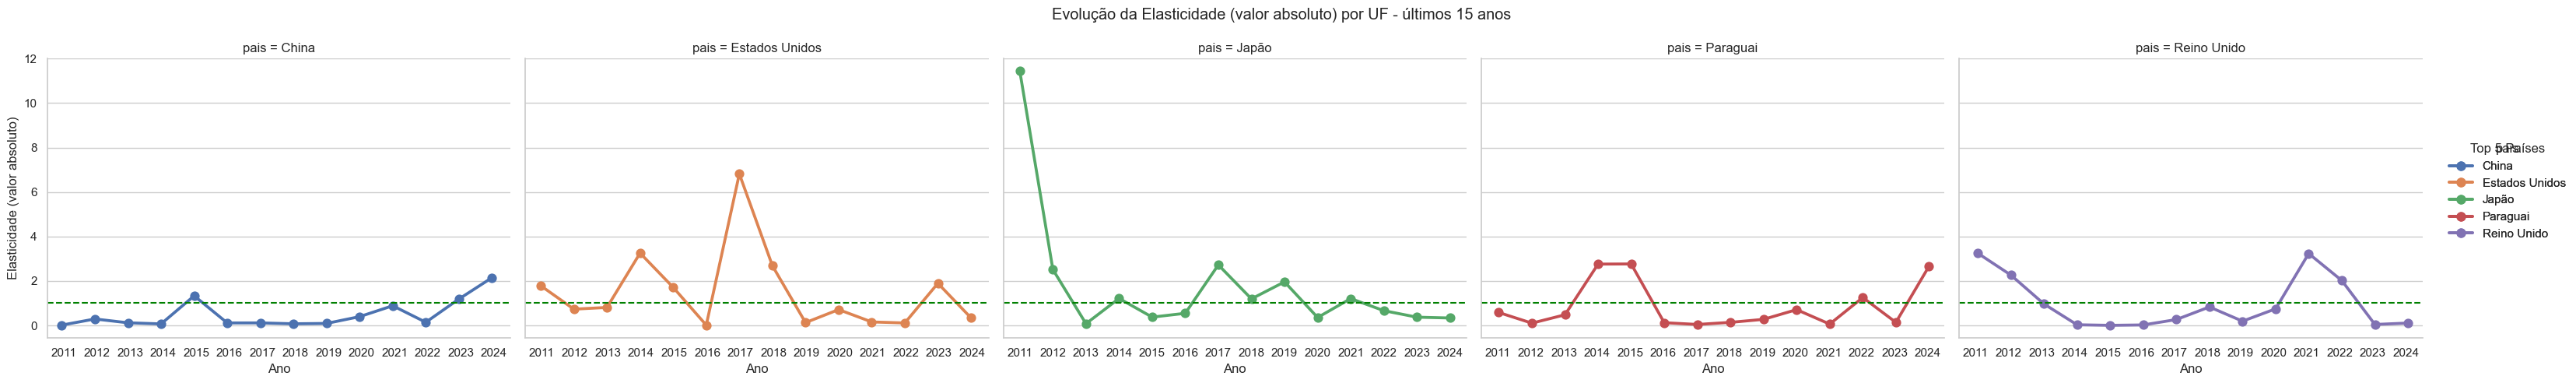

,Elasticidade (|E|),Classificação,Interpretação
0,E > 1,Elástica,Preço varia muito em relação à quantidade
1,E < 1,Inelástica,Preço varia pouco em relação à quantidade
2,E = 1,Elasticidade unitária,Variação proporcional entre preço e quantidade


In [164]:
# Definir o tema
sns.set_theme(style="whitegrid")

# Gerar o gráfico com catplot
g = sns.catplot(
    data=df_vinhos_pm,
    x='ano',
    y='elasticidade',
    hue='pais',
    col='pais',
    kind='point',
    height=5,
    aspect=1.2,
    markers='o',
    dodge=True
)

# Adiciona uma linha horizontal em cada subplot para Elasticidade = 1
for ax in g.axes.flat:
    ax.axhline(1, color='green', linestyle='--', label='Elasticidade = 1')

# Ajusta o título geral e eixos
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle(f'Evolução da Elasticidade (valor absoluto) por UF - últimos {delta_anos} anos')
g.set_axis_labels("Ano", "Elasticidade (valor absoluto)")
g.add_legend(title=f'Top {rank} Países')

plt.show()

# Criar DataFrame para interpretação
elasticidade = pd.DataFrame({
    "Elasticidade (|E|)": ["E > 1", "E < 1", "E = 1"],
    "Classificação": ["Elástica", "Inelástica", "Elasticidade unitária"],
    "Interpretação": [
        "Preço varia muito em relação à quantidade",
        "Preço varia pouco em relação à quantidade",
        "Variação proporcional entre preço e quantidade"
    ]
})

# Exibe a tabela
display(elasticidade)
